# Uso de GPU

In [22]:
import tensorflow as tf

print("TF version:", tf.__version__)
print("Built with CUDA:", tf.test.is_built_with_cuda())

gpus = tf.config.list_physical_devices("GPU")
print("GPUs:", gpus)

if gpus:
    for i, g in enumerate(gpus):
        details = tf.config.experimental.get_device_details(g)
        print(f"GPU {i} details:", details)
else:
    print("Nenhuma GPU visível para o TensorFlow.")

I0000 00:00:1780078757.354344 1242472 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


TF version: 2.21.0
Built with CUDA: True
GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]
GPU 0 details: {'compute_capability': (8, 9), 'device_name': 'NVIDIA GeForce RTX 4090'}
GPU 1 details: {'compute_capability': (8, 9), 'device_name': 'NVIDIA GeForce RTX 4090'}


# Análise demográfica

In [23]:
import pandas as pd

df_ext = pd.read_csv("image_data_sMCI_pMCI_extremos.csv")

# 1 linha por paciente (metadados do conjunto)
pt = (
    df_ext.sort_values(["ID_PT", "MRI_DATE", "ID_IMG"])
    .groupby("ID_PT", as_index=False)
    .agg(
        GROUP=("GROUP", "first"),
        SEX=("SEX", "first"),
        n_linhas=("ID_IMG", "size"),
    )
)

# conjuntos = pacientes com exatamente 3 linhas
pt = pt[pt["n_linhas"] == 3].copy()
pt["n_conjuntos"] = 1  # 1 conjunto por paciente válido

# --- totais ---
n_conjuntos_total = len(pt)
n_linhas_total = int(pt["n_linhas"].sum())
print("Conjuntos (pacientes com 3 linhas):", n_conjuntos_total)
print("Linhas totais:", n_linhas_total)
print("Checagem linhas/3:", n_linhas_total / 3)

# --- por GROUP ---
print("\nPor GROUP:")
print(pt["GROUP"].value_counts().sort_index())
# ou só contagem de conjuntos:
# print(pt.groupby("GROUP")["n_conjuntos"].sum())

# --- por SEX ---
print("\nPor SEX:")
print(pt["SEX"].value_counts().sort_index())

# --- GROUP × SEX ---
print("\nGROUP × SEX:")
print(pd.crosstab(pt["GROUP"], pt["SEX"], margins=True))

Conjuntos (pacientes com 3 linhas): 525
Linhas totais: 1575
Checagem linhas/3: 525.0

Por GROUP:
GROUP
pMCI    128
sMCI    397
Name: count, dtype: int64

Por SEX:
SEX
F    222
M    303
Name: count, dtype: int64

GROUP × SEX:
SEX      F    M  All
GROUP               
pMCI    54   74  128
sMCI   168  229  397
All    222  303  525


In [24]:
df_ext.groupby("GROUP")["ID_PT"].nunique()

GROUP
pMCI    128
sMCI    397
Name: ID_PT, dtype: int64

In [25]:
dist_pacientes = (
    df_ext.drop_duplicates(subset=["ID_PT", "GROUP"])
    .groupby(["GROUP", "SEX"])["ID_PT"]
    .nunique()
    .unstack(fill_value=0)
)

dist_pacientes

SEX,F,M
GROUP,,
pMCI,54,74
sMCI,168,229


In [26]:
pts = df_ext.groupby(["GROUP", "ID_PT"], as_index=False)["AGE"].min()

for g in ["sMCI", "pMCI"]:
    a = pts.loc[pts["GROUP"] == g, "AGE"]
    print(
        f"{g}: n={a.count()}, "
        f"min={a.min():.1f}, max={a.max():.1f}, "
        f"media={a.mean():.2f}, desvio={a.std():.2f}"
    )

sMCI: n=397, min=55.0, max=91.0, media=73.52, desvio=7.48
pMCI: n=128, min=57.0, max=89.0, media=75.04, desvio=7.01


In [27]:
adnimerge = pd.read_csv("csvs/adnimerged.csv")
df_ext = pd.read_csv("image_data_sMCI_pMCI_extremos.csv")

cols = ["ID_IMG", "MMSE_SCORE", "CDR_GLOBAL", "ADAS_SCORE", "FAQ_SCORE"]

adni_sub = adnimerge.loc[:, cols].copy()
adni_sub["ID_IMG"] = adni_sub["ID_IMG"].astype(str).str.strip()
adni_sub = adni_sub.drop_duplicates(subset=["ID_IMG"], keep="last")

df_ext["ID_IMG"] = df_ext["ID_IMG"].astype(str).str.strip()
df_ext = df_ext.merge(adni_sub, on="ID_IMG", how="left", validate="many_to_one")

In [28]:
pts = (
    df_ext.sort_values(["GROUP", "ID_PT", "MRI_DATE"])
    .drop_duplicates(subset=["GROUP", "ID_PT"], keep="first")
)

pts.groupby("GROUP")[["MMSE_SCORE", "FAQ_SCORE", "CDR_GLOBAL", "ADAS_SCORE"]].agg(["mean", "std", "count"])

MMSE_SCORE                 FAQ_SCORE                 CDR_GLOBAL  \
            mean       std count      mean       std count       mean   
GROUP                                                                   
pMCI   26.039062  2.249768   128  6.453125  4.619131   128   0.507812   
sMCI   27.758186  1.822132   397  2.503778  3.573628   397   0.497481   

                      ADAS_SCORE                  
            std count       mean       std count  
GROUP                                             
pMCI   0.062253   128  14.382891  5.055354   128  
sMCI   0.035444   397   9.491788  3.917522   397

# Modelagem

Nested CV + SVM + downsampling. Seleção por split: **corr/var** (`USE_CORR_VAR`) → **SelectKBest** (`USE_SELECT_KBEST`, `K_BEST_GRID`) → z-score → SVM.


In [8]:
# Funções compartilhadas — nested CV 5×5 + SVM + downsampling (só no treino)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.feature_selection import SelectKBest, VarianceThreshold, f_classif
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    PrecisionRecallDisplay,
    RocCurveDisplay,
    average_precision_score,
    balanced_accuracy_score,
    confusion_matrix,
    f1_score,
    matthews_corrcoef,
    precision_score,
    roc_auc_score,
)
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVC

METRIC_COLS = [
    "auc", "auc_pr", "bal_acc", "mcc",
    "sens_pMCI", "spec_sMCI", "prec_pMCI", "f1_pMCI",
]
CLASS_NAMES = {0: "sMCI", 1: "pMCI"}
SEED = 42
K_OUT, K_IN = 5, 5
C_GRID = [1e-3, 0.01, 0.1, 1.0, 10.0]
# C_GRID = np.logspace(-4, 0, num=13).tolist()
CORR_THR = 0.95
VAR_THR = 0.01
USE_CORR_VAR = False         # correlação + variância por split
USE_SELECT_KBEST = False      # SelectKBest (após corr/var) por split
K_BEST_GRID = [30, 50, 100, 200]  # tunado no CV interno; ignorado se USE_SELECT_KBEST=False


def fold_metrics(y_true, scores, pred) -> dict:
    tn, fp, fn, tp = confusion_matrix(y_true, pred, labels=[0, 1]).ravel()
    return {
        "auc": float(roc_auc_score(y_true, scores)),
        "auc_pr": float(average_precision_score(y_true, scores)),
        "bal_acc": float(balanced_accuracy_score(y_true, pred)),
        "mcc": float(matthews_corrcoef(y_true, pred)),
        "sens_pMCI": float(tp / (tp + fn)) if (tp + fn) else float("nan"),
        "spec_sMCI": float(tn / (tn + fp)) if (tn + fp) else float("nan"),
        "prec_pMCI": float(precision_score(y_true, pred, pos_label=1, zero_division=0)),
        "f1_pMCI": float(f1_score(y_true, pred, pos_label=1, zero_division=0)),
    }


# def clf(C: float) -> LinearSVC:
#     return LinearSVC(C=C, max_iter=75000, dual="auto", random_state=SEED)
def clf(C: float) -> LinearSVC:
    # dual=False é obrigatório quando usamos penalty='l1'
    return LinearSVC(penalty='l1', dual=False, C=C, max_iter=75000, random_state=SEED)

def downsample_patient_indices(idx, y, seed: int) -> np.ndarray:
    """Mesmo nº de índices sMCI e pMCI no conjunto referenciado por idx."""
    idx = np.asarray(idx)
    rng = np.random.default_rng(seed)
    i0 = idx[y[idx] == 0]
    i1 = idx[y[idx] == 1]
    n = min(len(i0), len(i1))
    pick = np.concatenate([rng.choice(i0, n, replace=False), rng.choice(i1, n, replace=False)])
    rng.shuffle(pick)
    return pick


# --- Correlação + variância (sem SelectKBest) ---
def corr_keep_indices(X: np.ndarray, thr: float) -> np.ndarray:
    xf = np.nan_to_num(X, nan=0.0, posinf=0.0, neginf=0.0)
    if xf.shape[0] < 2:
        return np.arange(X.shape[1], dtype=int)
    c = np.corrcoef(xf.T)
    keep: list[int] = []
    for j in range(c.shape[0]):
        if all(not (np.isfinite(c[j, k]) and abs(c[j, k]) > thr) for k in keep):
            keep.append(j)
    return np.asarray(keep, dtype=int)


def var_keep_indices(X: np.ndarray, thr: float) -> np.ndarray:
    xf = np.nan_to_num(X, nan=0.0, posinf=0.0, neginf=0.0)
    vt = VarianceThreshold(threshold=thr)
    vt.fit(xf)
    return np.where(vt.get_support())[0]


def corr_var_keep(X_train: np.ndarray, corr_thr: float, var_thr: float) -> np.ndarray:
    """Máscara de colunas: só correlação + variância."""
    if not USE_CORR_VAR:
        return np.arange(X_train.shape[1], dtype=int)
    k_corr = corr_keep_indices(X_train, corr_thr)
    k_var = var_keep_indices(X_train[:, k_corr], var_thr)
    return k_corr[k_var]


# --- SelectKBest exclusivo (requer y; colunas já filtradas por corr/var) ---
def select_kbest_keep(X_train: np.ndarray, y_train: np.ndarray, k: int) -> np.ndarray:
    """Índices locais (0..n_cols-1) das colunas de X_train escolhidas por f_classif."""
    X = np.nan_to_num(X_train, nan=0.0, posinf=0.0, neginf=0.0)
    n_cols = X.shape[1]
    if n_cols == 0:
        return np.arange(0, dtype=int)
    k = min(int(k), n_cols)
    if k < 1:
        return np.arange(n_cols, dtype=int)
    skb = SelectKBest(score_func=f_classif, k=k)
    skb.fit(X, np.asarray(y_train, dtype=int))
    return np.where(skb.get_support())[0]


def build_column_keep(X_train: np.ndarray, y_train: np.ndarray, k: int) -> np.ndarray:
    """Ordem: corr/var → SelectKBest (opcional) → índices no X original."""
    keep = corr_var_keep(X_train, CORR_THR, VAR_THR)
    if USE_SELECT_KBEST:
        k_local = select_kbest_keep(X_train[:, keep], y_train, k)
        keep = keep[k_local]
    return keep


def apply_column_mask(X: np.ndarray, keep: np.ndarray) -> np.ndarray:
    return X[:, keep]


def scale_train_val(X_fit, X_other):
    scaler = StandardScaler()
    return scaler.fit_transform(X_fit), scaler.transform(X_other)


def _k_grid():
    return K_BEST_GRID if USE_SELECT_KBEST else [0]


def nested_cv_patient_level(
    X, y, test_name: str, *, collect_fold_details: bool = False
):
    """Testes 1 e 2: StratifiedKFold + corr/var + SelectKBest + z-score por split."""
    results = []
    fold_details: list[dict] = []
    outer = StratifiedKFold(K_OUT, shuffle=True, random_state=SEED)
    for fold, (tr, te) in enumerate(outer.split(X, y), start=1):
        best_C, best_k = C_GRID[0], K_BEST_GRID[0]
        best_inner_auc = -1.0
        inner = StratifiedKFold(K_IN, shuffle=True, random_state=SEED + fold)

        for k in _k_grid():
            for C in C_GRID:
                inner_aucs = []
                seed_extra = int(k) if USE_SELECT_KBEST else 0
                for in_tr, in_va in inner.split(X[tr], y[tr]):
                    keep = build_column_keep(X[tr][in_tr], y[tr][in_tr], k)
                    bal = downsample_patient_indices(
                        in_tr, y[tr], SEED + fold + int(C * 1e4) + seed_extra
                    )
                    X_fit = apply_column_mask(X[tr][bal], keep)
                    X_va = apply_column_mask(X[tr][in_va], keep)
                    X_fit_z, X_va_z = scale_train_val(X_fit, X_va)

                    model = clf(C)
                    model.fit(X_fit_z, y[tr][bal])
                    if len(np.unique(y[tr][in_va])) > 1:
                        inner_aucs.append(
                            roc_auc_score(y[tr][in_va], model.decision_function(X_va_z))
                        )

                if inner_aucs and np.mean(inner_aucs) > best_inner_auc:
                    best_inner_auc = float(np.mean(inner_aucs))
                    best_C, best_k = C, k

        keep = build_column_keep(X[tr], y[tr], best_k)
        bal = downsample_patient_indices(tr, y, SEED + fold)
        X_fit = apply_column_mask(X[bal], keep)
        X_te_sel = apply_column_mask(X[te], keep)
        X_fit_z, X_te_z = scale_train_val(X_fit, X_te_sel)

        model = clf(best_C)
        model.fit(X_fit_z, y[bal])
        scores = model.decision_function(X_te_z)
        pred = model.predict(X_te_z)

        row = {
            "test": test_name,
            "fold": fold,
            "best_C": best_C,
            "best_k": int(best_k) if USE_SELECT_KBEST else None,
            "n_features": int(len(keep)),
            "n_train_bal": len(bal),
            "n_test": len(te),
            "n_test_pMCI": int(y[te].sum()),
            **fold_metrics(y[te], scores, pred),
        }
        results.append(row)
        if collect_fold_details:
            fold_details.append({
                "fold": fold,
                "best_C": best_C,
                "best_k": best_k,
                "y_test": np.asarray(y[te], dtype=int),
                "scores": np.asarray(scores, dtype=float),
                "pred": np.asarray(pred, dtype=int),
                "X_fit_z": X_fit_z,
                "X_te_z": X_te_z,
                "y_fit": np.asarray(y[bal], dtype=int),
            })

    df = pd.DataFrame(results)
    if collect_fold_details:
        return df, fold_details
    return df


# --- Gráficos de diagnóstico (teste externo por fold) ---
def plot_score_histogram(y, scores, *, title="Scores no teste", ax=None):
    ax = ax or plt.gca()
    ax.hist(scores[y == 0], bins=25, alpha=0.6, label=CLASS_NAMES[0])
    ax.hist(scores[y == 1], bins=25, alpha=0.6, label=CLASS_NAMES[1])
    ax.axvline(0.0, color="k", linestyle="--", linewidth=1, label="limiar 0")
    ax.set_xlabel("decision_function")
    ax.set_ylabel("pacientes")
    ax.set_title(title)
    ax.legend()
    return ax


def plot_roc_all_folds(fold_details, *, title="ROC — folds externos", ax=None):
    ax = ax or plt.gca()
    for fd in fold_details:
        if len(np.unique(fd["y_test"])) < 2:
            continue
        RocCurveDisplay.from_predictions(
            fd["y_test"], fd["scores"], ax=ax, name=f"fold {fd['fold']}"
        )
    ax.plot([0, 1], [0, 1], "k--", linewidth=1)
    ax.set_title(title)
    ax.legend(loc="lower right", fontsize=8)
    return ax


def plot_pr_all_folds(fold_details, *, title="PR — folds externos", ax=None):
    ax = ax or plt.gca()
    for fd in fold_details:
        if len(np.unique(fd["y_test"])) < 2:
            continue
        PrecisionRecallDisplay.from_predictions(
            fd["y_test"], fd["scores"], ax=ax, name=f"fold {fd['fold']}"
        )
    ax.set_title(title)
    ax.legend(loc="lower left", fontsize=8)
    return ax


def plot_confusion_aggregate(fold_details, *, title="Confusão agregada (teste)", ax=None):
    y_all = np.concatenate([fd["y_test"] for fd in fold_details])
    pred_all = np.concatenate([fd["pred"] for fd in fold_details])
    ax = ax or plt.gca()
    ConfusionMatrixDisplay.from_predictions(
        y_all, pred_all, display_labels=[CLASS_NAMES[0], CLASS_NAMES[1]], ax=ax
    )
    ax.set_title(title)
    return ax


def plot_pca_fold(fd, *, title=None, ax=None):
    pca = PCA(n_components=2, random_state=SEED)
    Z_fit = pca.fit_transform(fd["X_fit_z"])
    Z_te = pca.transform(fd["X_te_z"])
    Z = np.vstack([Z_fit, Z_te])
    y_plot = np.concatenate([fd["y_fit"], fd["y_test"]])

    ax = ax or plt.gca()
    for label in (0, 1):
        m = y_plot == label
        ax.scatter(Z[m, 0], Z[m, 1], alpha=0.5, s=24, label=CLASS_NAMES[label])
    ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%})")
    ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%})")
    ax.set_title(title or f"PCA — fold externo {fd['fold']}")
    ax.legend(fontsize=8)
    return ax


def plot_cv_diagnostics(fold_details, test_name, *, hist_fold=1, pca_fold=1):
    fd_hist = next(fd for fd in fold_details if fd["fold"] == hist_fold)
    fd_pca = next(fd for fd in fold_details if fd["fold"] == pca_fold)

    fig, axes = plt.subplots(2, 2, figsize=(11, 9))
    plot_score_histogram(
        fd_hist["y_test"], fd_hist["scores"],
        title=f"{test_name} — scores (fold {hist_fold}, teste)", ax=axes[0, 0],
    )
    plot_roc_all_folds(fold_details, title=f"{test_name} — ROC", ax=axes[0, 1])
    plot_confusion_aggregate(
        fold_details, title=f"{test_name} — confusão agregada", ax=axes[1, 0],
    )
    plot_pca_fold(fd_pca, title=f"{test_name} — PCA (fold {pca_fold})", ax=axes[1, 1])
    fig.suptitle(test_name, fontsize=12, y=1.02)
    fig.tight_layout()
    plt.show()

    fig2, ax2 = plt.subplots(figsize=(6, 5))
    plot_pr_all_folds(fold_details, title=f"{test_name} — PR", ax=ax2)
    fig2.tight_layout()
    plt.show()


def print_summary(df: pd.DataFrame) -> None:
    print(f"\n=== {df['test'].iloc[0]} ===")
    display(df)
    print("\nResumo (média ± desvio entre folds):")
    for col in METRIC_COLS:
        print(f"  {col:12s}: {df[col].mean():.3f} ± {df[col].std():.3f}")


## Teste 1 — média global das 60 linhas (baseline)


In [42]:
# # --- Teste 1: média global das 60 linhas (baseline) ---

# import pandas as pd
# import numpy as np

# # PATH = "csvs/abordagem_4_sMCI_pMCI_extremos/all_features_merge_clean.csv"
# PATH = "csvs/abordagem_4_sMCI_pMCI_extremos/all_features_merge_hippocampus_clean.csv"

# meta = {"ID_PT", "GROUP", "SEX"}
# df = pd.read_csv(PATH).sort_values("ID_PT")
# feat = [c for c in df.columns if c not in meta]

# X, y = [], []
# for _, g in df.groupby("ID_PT", sort=False):
#     # if len(g) != 60:
#     if len(g) != 6:
#         continue
#     X.append(g[feat].to_numpy(float).mean(axis=0))
#     y.append(int(g["GROUP"].iloc[0]))
# X, y = np.vstack(X), np.array(y, dtype=int)
# print(f"Teste 1 | {len(y)} pacientes | dim={X.shape[1]} | sMCI={(y==0).sum()} | pMCI={(y==1).sum()}")

# results_t1, details_t1 = nested_cv_patient_level(
#     X, y, "teste1_media_60linhas", collect_fold_details=True
# )
# print_summary(results_t1)
# plot_cv_diagnostics(details_t1, "teste1_media_60linhas")


## Teste 2 — wide temporal (1 linha/paciente)


Teste 2 | 525 pacientes | dim=90


/home/pgirardi/.pyenvs/graphs/lib/python3.12/site-packages/sklearn/svm/_base.py:1258: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/home/pgirardi/.pyenvs/graphs/lib/python3.12/site-packages/sklearn/svm/_base.py:1258: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/home/pgirardi/.pyenvs/graphs/lib/python3.12/site-packages/sklearn/svm/_base.py:1258: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(



=== teste2_wide_temporal ===


,test,fold,best_C,best_k,n_features,n_train_bal,n_test,n_test_pMCI,auc,auc_pr,bal_acc,mcc,sens_pMCI,spec_sMCI,prec_pMCI,f1_pMCI
0,teste2_wide_temporal,1,0.1,None,90,204,105,26,0.695229,0.443045,0.630477,0.228283,0.615385,0.645570,0.363636,0.457143
1,teste2_wide_temporal,2,0.1,None,90,204,105,26,0.786758,0.615925,0.707157,0.362442,0.730769,0.683544,0.431818,0.542857
2,teste2_wide_temporal,3,0.1,None,90,204,105,26,0.837390,0.660885,0.719572,0.394437,0.692308,0.746835,0.473684,0.562500
3,teste2_wide_temporal,4,0.1,None,90,206,105,25,0.765500,0.517543,0.705000,0.351185,0.760000,0.650000,0.404255,0.527778
4,teste2_wide_temporal,5,0.1,None,90,206,105,25,0.713500,0.550807,0.690000,0.331754,0.680000,0.700000,0.414634,0.515152



Resumo (média ± desvio entre folds):
  auc         : 0.760 ± 0.057
  auc_pr      : 0.558 ± 0.085
  bal_acc     : 0.690 ± 0.035
  mcc         : 0.334 ± 0.063
  sens_pMCI   : 0.696 ± 0.055
  spec_sMCI   : 0.685 ± 0.041
  prec_pMCI   : 0.418 ± 0.040
  f1_pMCI     : 0.521 ± 0.040


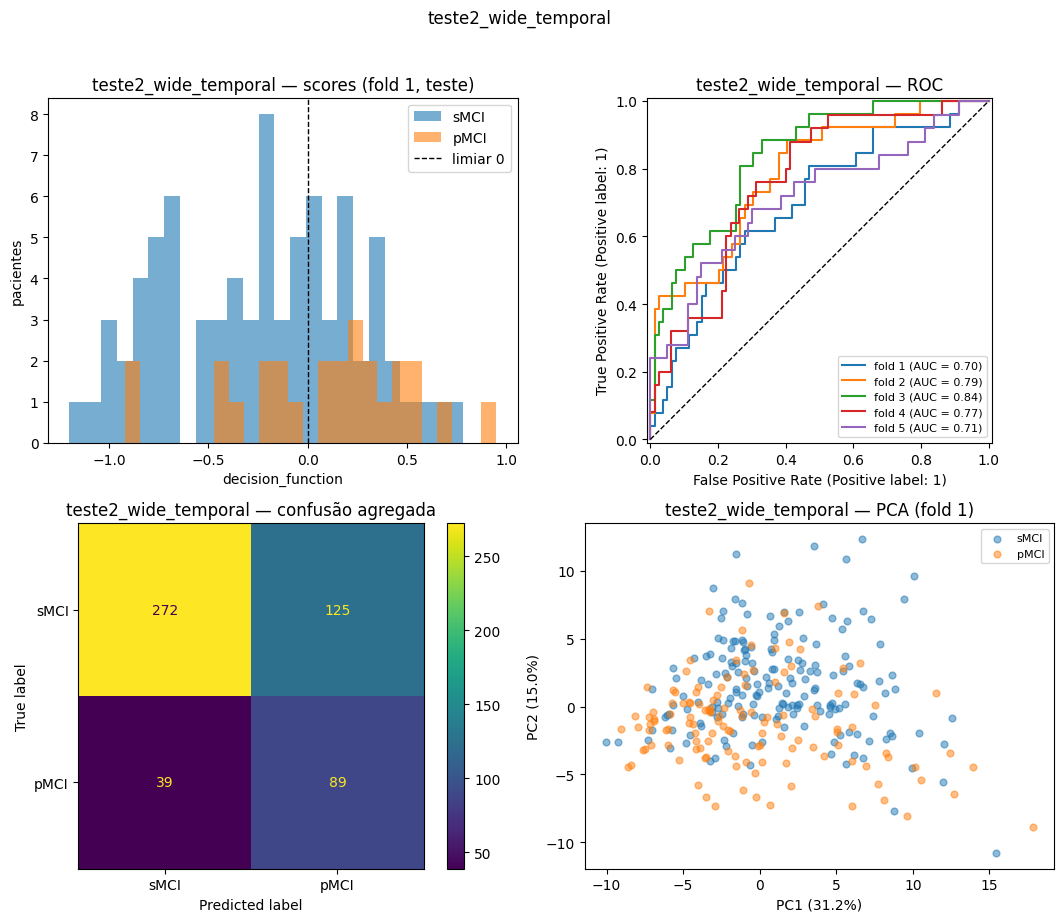

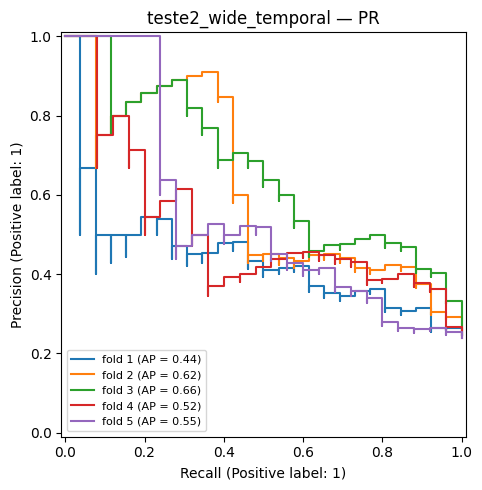

In [9]:
# --- Teste 2: 1 linha/paciente; ROI × T1/T2/T3 nas colunas ---
# PATH = "csvs/abordagem_4_sMCI_pMCI_extremos/all_features_patient_temporal.csv"
PATH = "csvs/abordagem_4_sMCI_pMCI_extremos/features_displacement_article_hippocampus_temporal.csv"

meta = {"ID_PT", "GROUP", "SEX"}
df = pd.read_csv(PATH)
X = df.drop(columns=meta).to_numpy(float)
y = df["GROUP"].to_numpy(int)
print(f"Teste 2 | {len(y)} pacientes | dim={X.shape[1]}")

results_t2, details_t2 = nested_cv_patient_level(
    X, y, "teste2_wide_temporal", collect_fold_details=True
)

print_summary(results_t2)
plot_cv_diagnostics(details_t2, "teste2_wide_temporal")


## Teste 3 — deltas / slopes (Δ₁₂, Δ₁₃, Δ₂₃)

CSV: `all_features_patient_deltas_hippocampus.csv` (gerado em `features_selection.ipynb`).

Ajuste `FEATURE_KIND`: `"delta"` | `"slope"` | `"both"`. Opcional: `TEMPORAL_PAIRS` = `("12", "13", "23")` ou subconjunto, ex. `("13",)`.


Teste 3 | 525 pacientes | dim=66 | kind=slope | pairs=('12', '13', '23')


/home/pgirardi/.pyenvs/colab/lib/python3.12/site-packages/sklearn/svm/_base.py:1237: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/home/pgirardi/.pyenvs/colab/lib/python3.12/site-packages/sklearn/svm/_base.py:1237: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/home/pgirardi/.pyenvs/colab/lib/python3.12/site-packages/sklearn/svm/_base.py:1237: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/home/pgirardi/.pyenvs/colab/lib/python3.12/site-packages/sklearn/svm/_base.py:1237: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/home/pgirardi/.pyenvs/colab/lib/python3.12/site-packages/sklearn/svm/_base.py:1237: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/home/pgirardi/.pyenvs/colab/lib/python3.12/site-packages/sklearn


=== teste3_slope_pairs121323 ===


,test,fold,best_C,best_k,n_features,n_train_bal,n_test,n_test_pMCI,auc,auc_pr,bal_acc,mcc,sens_pMCI,spec_sMCI,prec_pMCI,f1_pMCI
0,teste3_slope_pairs121323,1,0.1,30,30,204,105,26,0.567186,0.314403,0.554528,0.094353,0.615385,0.493671,0.285714,0.390244
1,teste3_slope_pairs121323,2,0.1,30,30,204,105,26,0.723466,0.487659,0.668939,0.293937,0.692308,0.645570,0.391304,0.500000
2,teste3_slope_pairs121323,3,0.1,30,30,204,105,26,0.615871,0.364779,0.623905,0.219248,0.576923,0.670886,0.365854,0.447761
3,teste3_slope_pairs121323,4,10.0,30,30,206,105,25,0.595000,0.347175,0.575000,0.127827,0.600000,0.550000,0.294118,0.394737
4,teste3_slope_pairs121323,5,0.1,30,30,206,105,25,0.660000,0.314860,0.576250,0.138809,0.440000,0.712500,0.323529,0.372881



Resumo (média ± desvio entre folds):
  auc         : 0.632 ± 0.061
  auc_pr      : 0.366 ± 0.071
  bal_acc     : 0.600 ± 0.046
  mcc         : 0.175 ± 0.081
  sens_pMCI   : 0.585 ± 0.092
  spec_sMCI   : 0.615 ± 0.090
  prec_pMCI   : 0.332 ± 0.046
  f1_pMCI     : 0.421 ± 0.052


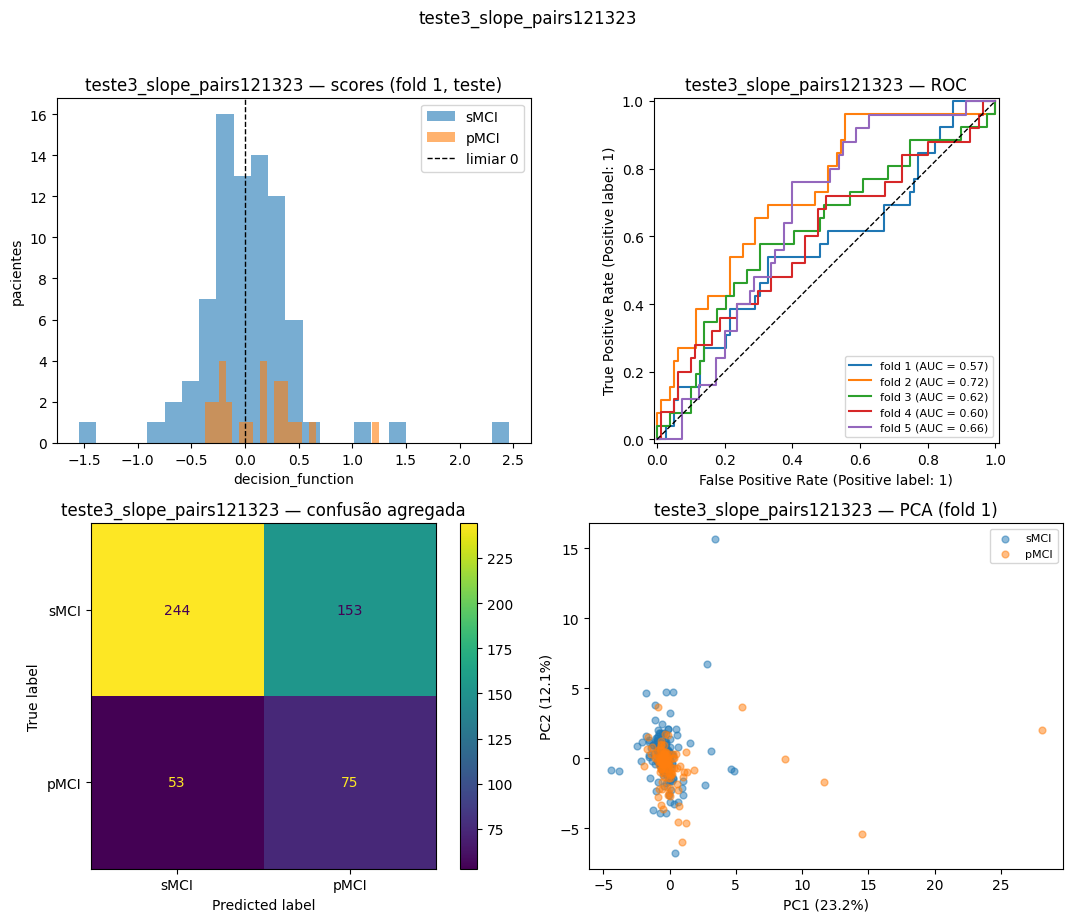

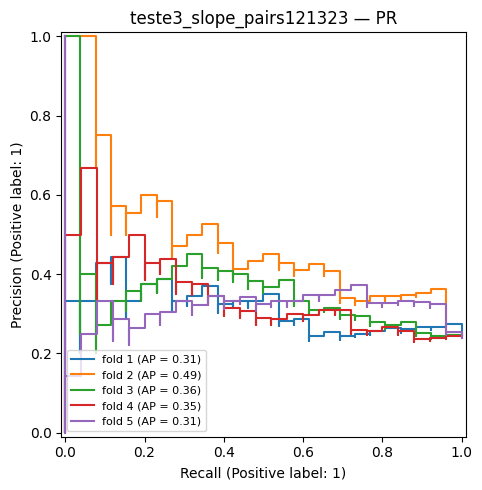

In [44]:
# --- Teste 3: 1 linha/paciente; Δ₁₂, Δ₁₃, Δ₂₃ (e slopes) por ROI×feature ---

# PATH = "csvs/abordagem_4_sMCI_pMCI_extremos/all_features_patient_deltas.csv"
PATH = "csvs/abordagem_4_sMCI_pMCI_extremos/all_features_patient_deltas_hippocampus.csv"

FEATURE_KIND = "slope"  # "delta" | "slope" | "both"
TEMPORAL_PAIRS = ("12", "13", "23")  # pares i2−i1, i3−i1, i3−i2

meta = {"ID_PT", "GROUP", "SEX"}


def select_temporal_features(
    columns,
    meta_cols,
    *,
    kind: str = "delta",
    pairs: tuple[str, ...] = ("12", "13", "23"),
) -> list[str]:
    """Colunas de feature a partir do CSV do Teste 3 (_delta12_, _slope13_, etc.)."""
    feat = [c for c in columns if c not in meta_cols]
    if kind == "delta":
        tokens = [f"_delta{p}_" for p in pairs]
        feat = [c for c in feat if any(t in c for t in tokens)]
    elif kind == "slope":
        tokens = [f"_slope{p}_" for p in pairs]
        feat = [c for c in feat if any(t in c for t in tokens)]
    elif kind == "both":
        tokens = [f"_delta{p}_" for p in pairs] + [f"_slope{p}_" for p in pairs]
        feat = [c for c in feat if any(t in c for t in tokens)]
    else:
        raise ValueError(f"FEATURE_KIND inválido: {kind!r}")
    return feat


df = pd.read_csv(PATH)
feat_cols = select_temporal_features(
    df.columns, meta, kind=FEATURE_KIND, pairs=TEMPORAL_PAIRS
)
if not feat_cols:
    raise ValueError(
        f"Nenhuma coluna para kind={FEATURE_KIND!r}, pairs={TEMPORAL_PAIRS}. "
        "Rode a célula Teste 3 em features_selection.ipynb."
    )

X = df[feat_cols].to_numpy(float)
y = df["GROUP"].to_numpy(int)
pairs_tag = "".join(TEMPORAL_PAIRS)
test_name = f"teste3_{FEATURE_KIND}_pairs{pairs_tag}"

print(
    f"Teste 3 | {len(y)} pacientes | dim={X.shape[1]} | "
    f"kind={FEATURE_KIND} | pairs={TEMPORAL_PAIRS}"
)

results_t3, details_t3 = nested_cv_patient_level(
    X, y, test_name, collect_fold_details=True
)
print_summary(results_t3)
plot_cv_diagnostics(details_t3, test_name)
